# Hotel Booking Demand - Exploratory Data Analysis
## 1. Environment Setup & Data Loading

In [26]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv('hotel_bookings.csv')
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
df.head(3)

Dataset shape: 119,390 rows, 32 columns


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


## 2. Target Variable Analysis

Not Canceled (0): 75,166 (62.96%)
Canceled (1):     44,224 (37.04%)


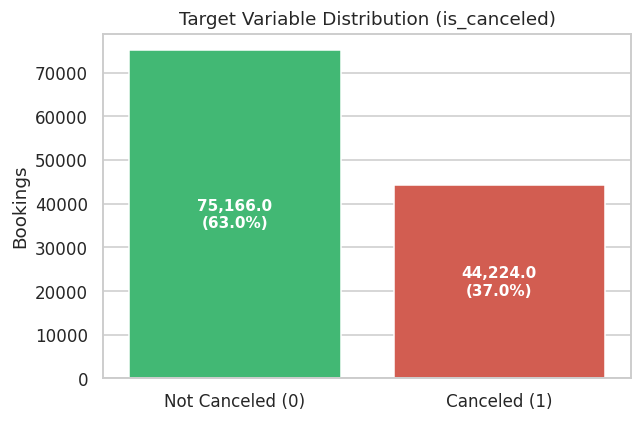

In [2]:
target_counts = df['is_canceled'].value_counts()
target_pct = df['is_canceled'].value_counts(normalize=True) * 100

print(f"Not Canceled (0): {target_counts[0]:,} ({target_pct[0]:.2f}%)")
print(f"Canceled (1):     {target_counts[1]:,} ({target_pct[1]:.2f}%)")

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=['Not Canceled (0)', 'Canceled (1)'], y=target_counts.values, palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_title("Target Variable Distribution (is_canceled)")
ax.set_ylabel("Bookings")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,}\n({p.get_height()/len(df)*100:.1f}%)",
                (p.get_x() + p.get_width()/2., p.get_height()/2),
                ha='center', va='center', fontsize=10, color='white', fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Missing Values & Domain Semantics

In [29]:
# 1. Explicit null values
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_df = pd.DataFrame({"missing_count": missing, "pct": (missing / len(df) * 100).round(2)})
print("Explicit Missing Values (NaN):")
print(missing_df)

# 2. Programmatic scan across ALL categorical features for hidden placeholders
cat_cols = df.select_dtypes(include=['object', 'string']).columns
placeholder_terms = ['Undefined', 'Unknown', '?', 'None', '-', '']

placeholder_records = []
for col in cat_cols:
    for term in placeholder_terms:
        count = (df[col].astype(str).str.strip() == term).sum()
        if count > 0:
            placeholder_records.append({
                'Column': col,
                'Placeholder': term,
                'Count': count,
                'Percentage (%)': round((count / len(df)) * 100, 4)
            })

placeholder_df = pd.DataFrame(placeholder_records)
print("\nDetected Categorical Placeholders Across All Features:")
print(placeholder_df.to_string(index=False))

# 3. Cancellation rate by agent & company missingness (Domain semantic check)
print("\nCancellation rate by agent missingness (True = Direct booking):")
agent_missing = df.groupby(df['agent'].isna())['is_canceled'].agg(['count', 'mean'])
agent_missing['cancellation_rate (%)'] = (agent_missing['mean'] * 100).round(2)
print(agent_missing[['count', 'cancellation_rate (%)']])

print("\nCancellation rate by company missingness (True = Private individual):")
company_missing = df.groupby(df['company'].isna())['is_canceled'].agg(['count', 'mean'])
company_missing['cancellation_rate (%)'] = (company_missing['mean'] * 100).round(2)
print(company_missing[['count', 'cancellation_rate (%)']])


Explicit Missing Values (NaN):
          missing_count    pct
company          112593  94.31
agent             16340  13.69
country             488   0.41
children              4   0.00

Detected Categorical Placeholders Across All Features:
              Column Placeholder  Count  Percentage (%)
                meal   Undefined   1169          0.9791
      market_segment   Undefined      2          0.0017
distribution_channel   Undefined      5          0.0042

Cancellation rate by agent missingness (True = Direct booking):
        count  cancellation_rate (%)
agent                               
False  103050                  39.00
True    16340                  24.66

Cancellation rate by company missingness (True = Private individual):
          count  cancellation_rate (%)
company                               
False      6797                  17.52
True     112593                  38.22


## 4. Duplicate Records

In [31]:
n_duplicates = df.duplicated().sum()
print(f"Duplicate rows: {n_duplicates:,} ({n_duplicates / len(df) * 100:.2f}%)")

df_dedup = df.drop_duplicates()
print(f"Full dataset cancellation rate:  {df['is_canceled'].mean() * 100:.2f}%")
print(f"Deduplicated cancellation rate:  {df_dedup['is_canceled'].mean() * 100:.2f}%")

# Market segments of duplicate bookings
dup_segments = df[df.duplicated(keep=False)]['market_segment'].value_counts(normalize=True) * 100
print("\nMarket segments of duplicate rows:")
print(dup_segments.round(2))

Duplicate rows: 31,994 (26.80%)
Full dataset cancellation rate:  37.04%
Deduplicated cancellation rate:  27.49%

Market segments of duplicate rows:
market_segment
Groups           41.61
Offline TA/TO    30.40
Online TA        20.59
Corporate         3.67
Direct            3.50
Complementary     0.19
Aviation          0.05
Name: proportion, dtype: float64


## 5. Categorical Cardinality & Numerical Distributions

Categorical Feature Cardinality:
 - hotel                    :   2 unique values
 - arrival_date_month       :  12 unique values
 - meal                     :   5 unique values
 - country                  : 177 unique values
 - market_segment           :   8 unique values
 - distribution_channel     :   5 unique values
 - reserved_room_type       :  10 unique values
 - assigned_room_type       :  12 unique values
 - deposit_type             :   3 unique values
 - customer_type            :   4 unique values
 - reservation_status       :   3 unique values
 - reservation_status_date  : 926 unique values

Numerical Features Summary:
                                  mean     std   min    50%     max  skewness
lead_time                       104.01  106.86  0.00  69.00   737.0      1.35
stays_in_weekend_nights           0.93    1.00  0.00   1.00    19.0      1.38
stays_in_week_nights              2.50    1.91  0.00   2.00    50.0      2.86
adults                            1.86    0.58  0.

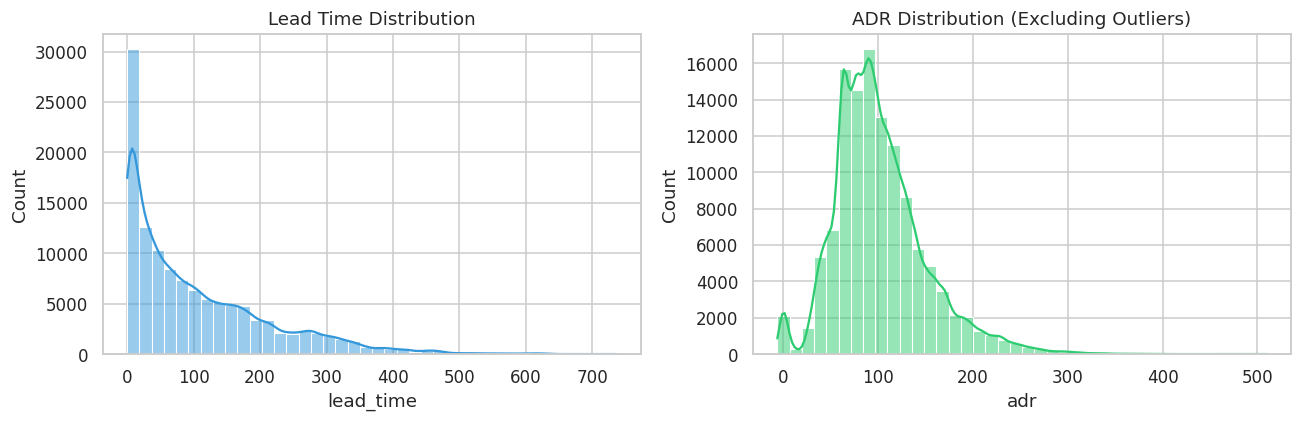

In [5]:
# Check cardinality of categorical columns
print("Categorical Feature Cardinality:")
for col in df.select_dtypes(include='object').columns:
    print(f" - {col:25s}: {df[col].nunique():3d} unique values")

# Summary statistics of numeric features
key_numeric = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'previous_cancellations',
    'previous_bookings_not_canceled', 'booking_changes',
    'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
    'total_of_special_requests'
]

stats_df = df[key_numeric].describe().T[['mean', 'std', 'min', '50%', 'max']]
stats_df['skewness'] = df[key_numeric].skew()
print("\nNumerical Features Summary:")
print(stats_df.round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['lead_time'], bins=40, kde=True, ax=axes[0], color='#3498db')
axes[0].set_title("Lead Time Distribution")

sns.histplot(df[df['adr'] < 600]['adr'], bins=40, kde=True, ax=axes[1], color='#2ecc71')
axes[1].set_title("ADR Distribution (Excluding Outliers)")
plt.tight_layout()
plt.show()

## 6. Categorical Features vs Cancellation

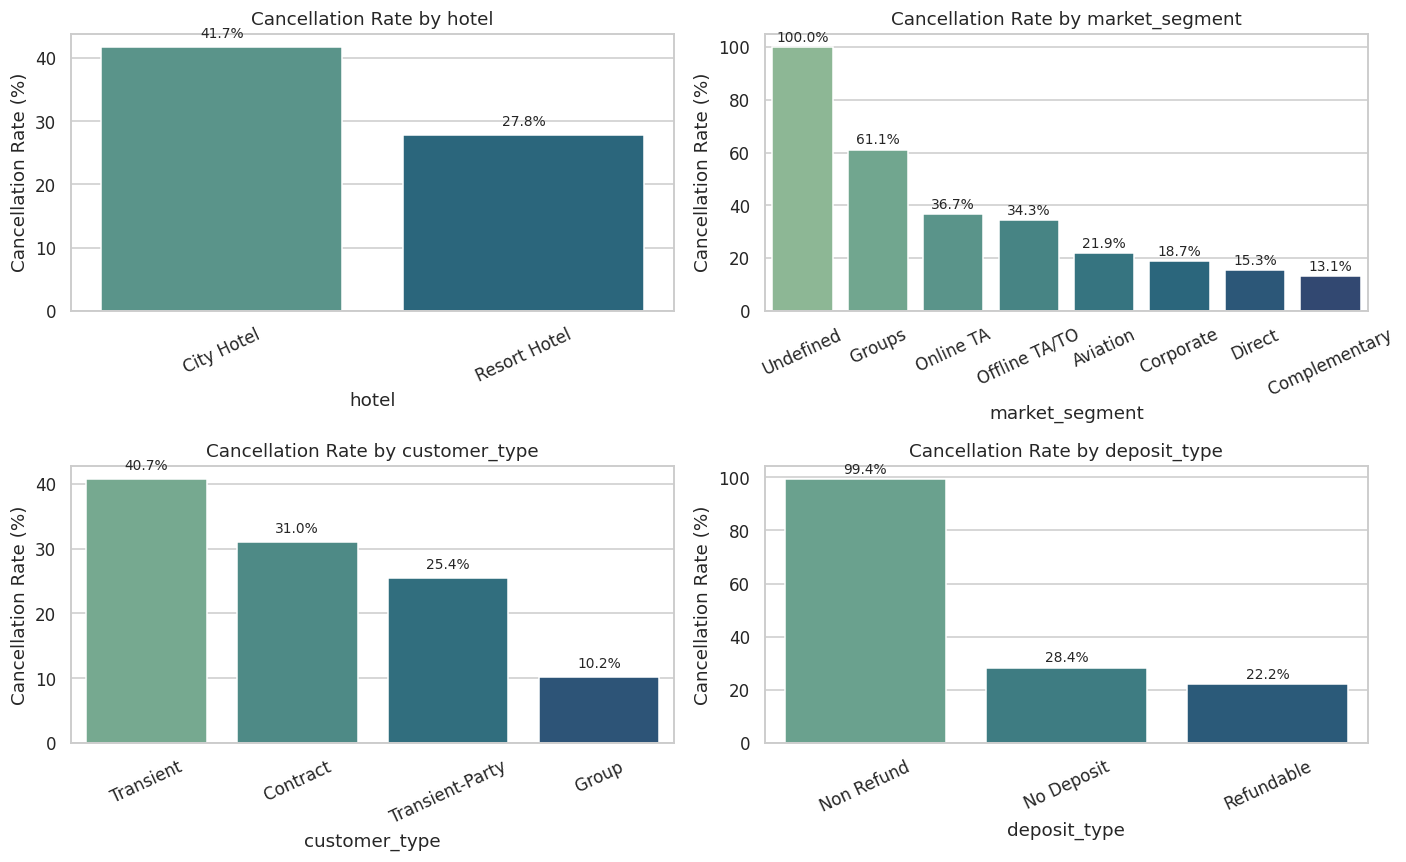

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
bivar_cats = ['hotel', 'market_segment', 'customer_type', 'deposit_type']

for ax, col in zip(axes.flatten(), bivar_cats):
    rate = df.groupby(col)['is_canceled'].agg(['count', 'mean']).sort_values('mean', ascending=False)
    rate['mean'] *= 100
    sns.barplot(x=rate.index, y=rate['mean'], ax=ax, palette="crest", hue=rate.index, legend=False)
    ax.set_title(f"Cancellation Rate by {col}")
    ax.set_ylabel("Cancellation Rate (%)")
    ax.tick_params(axis='x', rotation=25)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2., p.get_height() + 1),
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Special Requests & Customer Engagement

Special Requests vs Cancellation Rate:
                           count  cancellation_rate (%)
total_of_special_requests                              
0                          70318                  47.72
1                          33226                  22.02
2                          12969                  22.10
3                           2497                  17.86
4                            340                  10.59
5                             40                   5.00


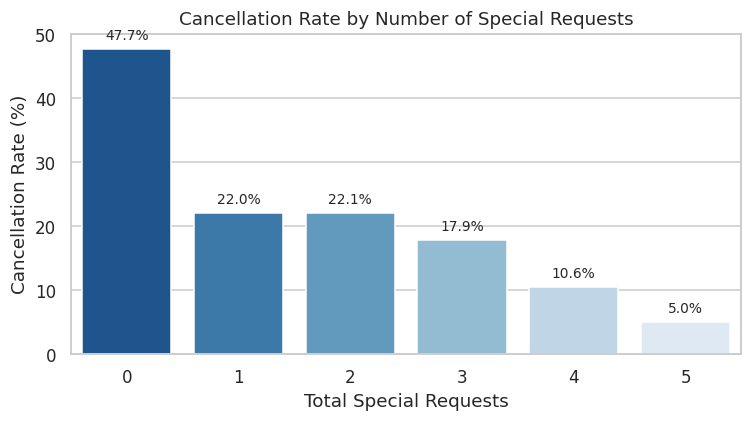

In [7]:
# Dedicated table for total_of_special_requests vs cancellation
special_req = df.groupby('total_of_special_requests')['is_canceled'].agg(['count', 'mean'])
special_req['cancellation_rate (%)'] = (special_req['mean'] * 100).round(2)
print("Special Requests vs Cancellation Rate:")
print(special_req[['count', 'cancellation_rate (%)']])

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=special_req.index, y=special_req['cancellation_rate (%)'], palette="Blues_r", ax=ax)
ax.set_title("Cancellation Rate by Number of Special Requests")
ax.set_ylabel("Cancellation Rate (%)")
ax.set_xlabel("Total Special Requests")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2., p.get_height() + 1),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 8. The Deposit Type Paradox

In [32]:
deposit_summary = df.groupby('deposit_type')['is_canceled'].agg(['count', 'sum', 'mean'])
deposit_summary['mean'] *= 100
deposit_summary.columns = ['Total Bookings', 'Total Canceled', 'Cancellation Rate (%)']
print(deposit_summary.round(2))

# Non-refund deposit breakdown by market segment
nr_segment = df[df['deposit_type'] == 'Non Refund']['market_segment'].value_counts()
print("\nNon-Refund deposits by market segment:")
print(nr_segment)

              Total Bookings  Total Canceled  Cancellation Rate (%)
deposit_type                                                       
No Deposit            104641           29694                  28.38
Non Refund             14587           14494                  99.36
Refundable               162              36                  22.22

Non-Refund deposits by market segment:
market_segment
Groups           9172
Offline TA/TO    5006
Corporate         334
Online TA          56
Direct             19
Name: count, dtype: int64


## 9. Geographic Analysis (Top Source Markets)

         count  cancellation_rate
country                          
PRT      48590              56.64
GBR      12129              20.22
FRA      10415              18.57
ESP       8568              25.41
DEU       7287              16.71
ITA       3766              35.40
IRL       3375              24.65
BEL       2342              20.24
BRA       2224              37.32
NLD       2104              18.39


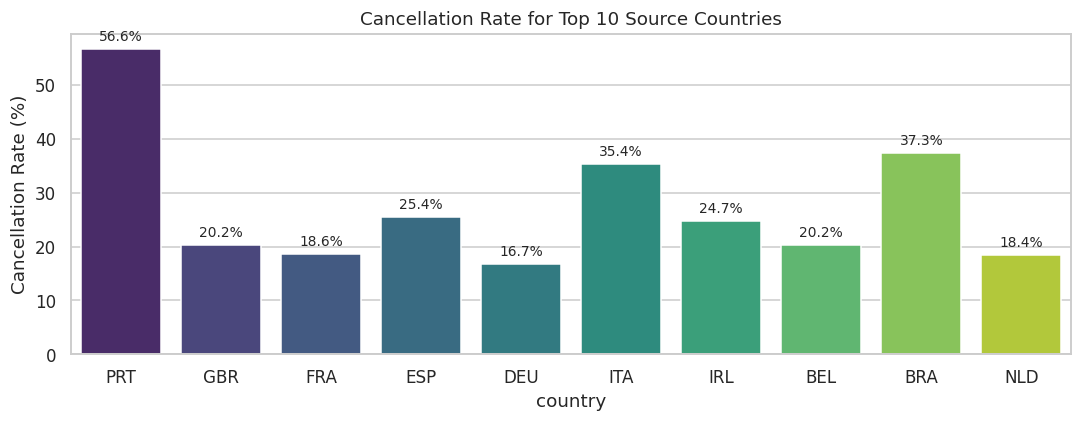

In [9]:
top_countries = df['country'].value_counts().head(10).index
country_df = df[df['country'].isin(top_countries)].groupby('country')['is_canceled'].agg(['count', 'mean'])
country_df['cancellation_rate'] = country_df['mean'] * 100
country_df = country_df.sort_values('count', ascending=False)
print(country_df[['count', 'cancellation_rate']].round(2))

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(x=country_df.index, y=country_df['cancellation_rate'], palette="viridis", ax=ax)
ax.set_title("Cancellation Rate for Top 10 Source Countries")
ax.set_ylabel("Cancellation Rate (%)")
for p in ax.patches:
    ax.annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2., p.get_height() + 1),
                ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 10. Lead Time & Seasonality

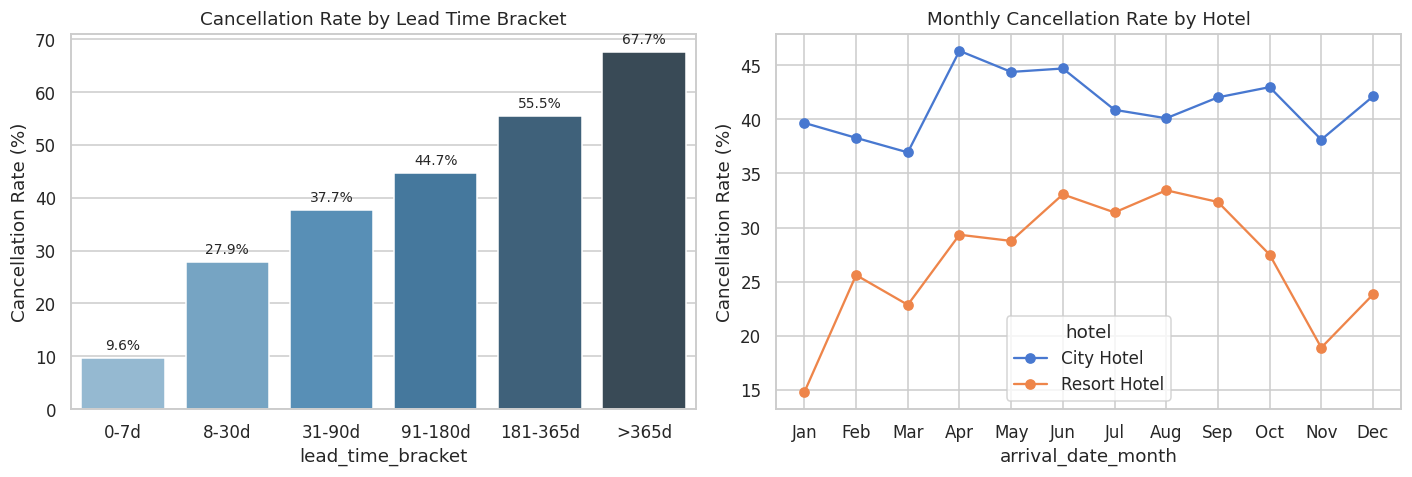

In [10]:
lead_bins = [0, 7, 30, 90, 180, 365, 1000]
lead_labels = ['0-7d', '8-30d', '31-90d', '91-180d', '181-365d', '>365d']
df['lead_time_bracket'] = pd.cut(df['lead_time'], bins=lead_bins, labels=lead_labels, include_lowest=True)

lead_cancellation = df.groupby('lead_time_bracket', observed=False)['is_canceled'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.barplot(x=lead_cancellation.index, y=lead_cancellation.values, ax=axes[0], palette="Blues_d")
axes[0].set_title("Cancellation Rate by Lead Time Bracket")
axes[0].set_ylabel("Cancellation Rate (%)")
for p in axes[0].patches:
    axes[0].annotate(f"{p.get_height():.1f}%", (p.get_x() + p.get_width()/2., p.get_height() + 1),
                    ha='center', va='bottom', fontsize=9)

month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_cancel = df.groupby(['arrival_date_month', 'hotel'])['is_canceled'].mean().unstack() * 100
month_cancel = month_cancel.reindex(month_order)
month_cancel.plot(kind='line', marker='o', ax=axes[1])
axes[1].set_title("Monthly Cancellation Rate by Hotel")
axes[1].set_ylabel("Cancellation Rate (%)")
axes[1].set_xticks(range(12))
axes[1].set_xticklabels([m[:3] for m in month_order])
plt.tight_layout()
plt.show()

## 11. Correlation Analysis

Top correlations with is_canceled:
 is_canceled                       1.000
lead_time                         0.293
previous_cancellations            0.110
adults                            0.060
days_in_waiting_list              0.054
adr                               0.048
stays_in_week_nights              0.025
children                          0.005
stays_in_weekend_nights          -0.002
babies                           -0.032
previous_bookings_not_canceled   -0.057
is_repeated_guest                -0.085
booking_changes                  -0.144
required_car_parking_spaces      -0.195
total_of_special_requests        -0.235
Name: is_canceled, dtype: float64


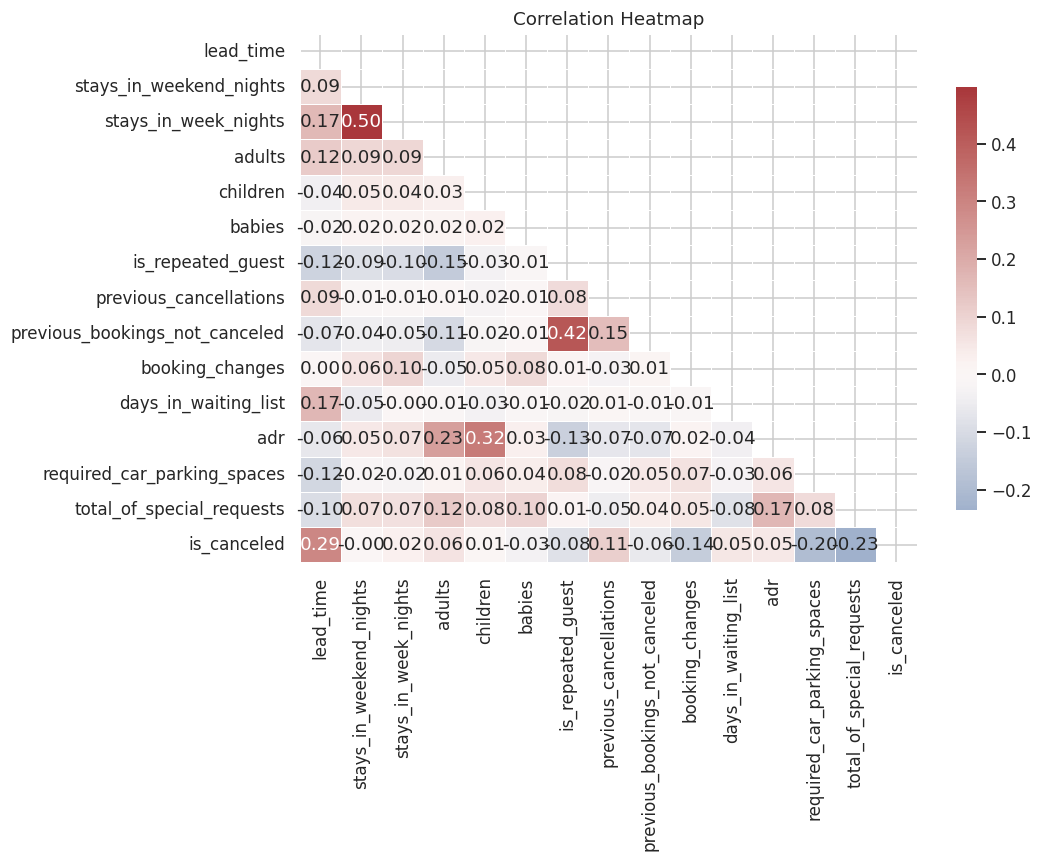

In [33]:
valid_numeric = [
    'lead_time', 'stays_in_weekend_nights', 'stays_in_week_nights',
    'adults', 'children', 'babies', 'is_repeated_guest',
    'previous_cancellations', 'previous_bookings_not_canceled',
    'booking_changes', 'days_in_waiting_list', 'adr',
    'required_car_parking_spaces', 'total_of_special_requests', 'is_canceled'
]

corr_matrix = df[valid_numeric].corr()
print("Top correlations with is_canceled:\n", corr_matrix['is_canceled'].sort_values(ascending=False).round(3))

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap="vlag", center=0, annot=True, fmt=".2f",
            linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 12. Outlier & Invalid Data Audit

Invalid records:
 - Zero guests:   180
 - Zero nights:   715
 - Negative ADR:  1
 - ADR > 1000:    1 (max: 5400.0)


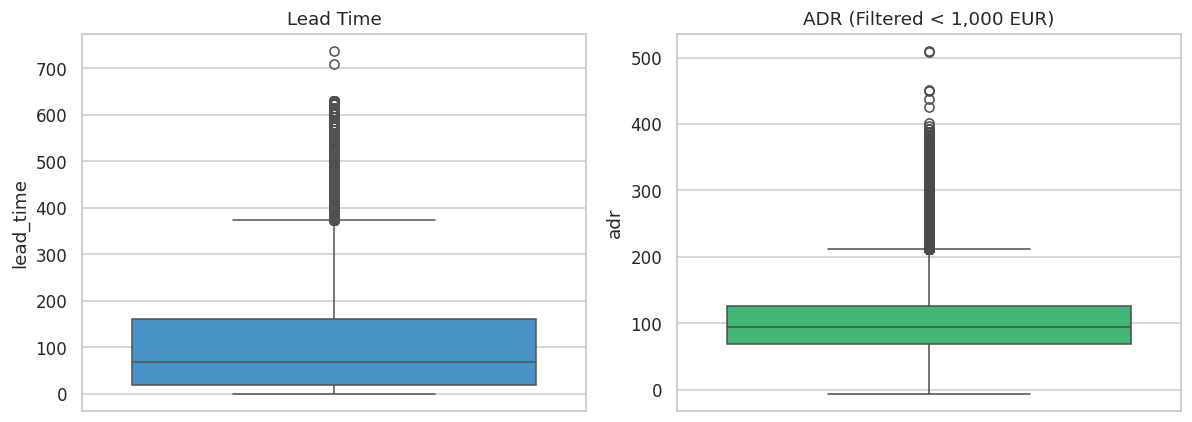

In [12]:
zero_guests = ((df['adults'] + df['children'].fillna(0) + df['babies']) == 0).sum()
zero_nights = ((df['stays_in_weekend_nights'] == 0) & (df['stays_in_week_nights'] == 0)).sum()
negative_adr = (df['adr'] < 0).sum()
extreme_adr = (df['adr'] > 1000).sum()

print("Invalid records:")
print(f" - Zero guests:   {zero_guests}")
print(f" - Zero nights:   {zero_nights}")
print(f" - Negative ADR:  {negative_adr}")
print(f" - ADR > 1000:    {extreme_adr} (max: {df['adr'].max()})")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df['lead_time'], ax=axes[0], color='#3498db')
axes[0].set_title("Lead Time")

sns.boxplot(y=df[df['adr'] < 1000]['adr'], ax=axes[1], color='#2ecc71')
axes[1].set_title("ADR (Filtered < 1,000 EUR)")
plt.tight_layout()
plt.show()

## 13. Data Leakage & Prediction-Time Feature Audit

In [34]:
# 1. Target outcome leakage
print("Target leakage check: 'reservation_status' vs 'is_canceled'")
print(pd.crosstab(df['reservation_status'], df['is_canceled']))

# 2. Operational leakage: room reassignment at check-in
room_diff = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)
room_diff_perf = df.groupby(room_diff)['is_canceled'].agg(['count', 'mean'])
room_diff_perf.index = ['Room Unchanged', 'Room Reassigned at Check-in']
room_diff_perf['cancellation_rate (%)'] = (room_diff_perf['mean'] * 100).round(2)
print("\nRoom Reassignment vs Cancellation:")
print(room_diff_perf[['count', 'cancellation_rate (%)']])

# 3. Temporal leakage: booking modifications post-booking
bchanges_perf = df.groupby(df['booking_changes'] > 0)['is_canceled'].agg(['count', 'mean'])
bchanges_perf.index = ['0 Modifications', '1+ Modifications']
bchanges_perf['cancellation_rate (%)'] = (bchanges_perf['mean'] * 100).round(2)
print("\nBooking Changes vs Cancellation:")
print(bchanges_perf[['count', 'cancellation_rate (%)']])

# 4. Post-booking queue leakage: days on waiting list
waiting_perf = df.groupby(df['days_in_waiting_list'] > 0)['is_canceled'].agg(['count', 'mean'])
waiting_perf.index = ['0 Days on Waiting List', '1+ Days on Waiting List']
waiting_perf['cancellation_rate (%)'] = (waiting_perf['mean'] * 100).round(2)
print("\nDays on Waiting List vs Cancellation:")
print(waiting_perf[['count', 'cancellation_rate (%)']])

# 5. Consolidated Prediction-Time Audit Table
audit_data = []
for col in df.columns:
    if col == 'is_canceled':
        cat = 'Target Variable'
        action = 'Predict'
        notes = 'Ground truth label'
    elif col in ['reservation_status', 'reservation_status_date']:
        cat = 'Target Outcome Leakage'
        action = 'Drop'
        notes = '100% determined at checkout/cancellation'
    elif col == 'assigned_room_type':
        cat = 'Operational Lookahead Leakage'
        action = 'Drop'
        notes = 'Assigned at check-in (reassigned cancels only 5.4%)'
    elif col == 'booking_changes':
        cat = 'Temporal Lookahead Leakage'
        action = 'Drop'
        notes = 'Accumulates post-booking (0 at booking time)'
    elif col == 'days_in_waiting_list':
        cat = 'Operational Queue Leakage'
        action = 'Drop'
        notes = 'Accrues while waiting for room confirmation'
    else:
        cat = 'Available at Booking Time'
        action = 'Retain'
        notes = 'Safe predictor available at reservation creation'
    audit_data.append({
        'Feature': col,
        'Availability Category': cat,
        'Modeling Action': action
    })

audit_df = pd.DataFrame(audit_data)
print("\nPrediction-Time Audit Summary:")
print(audit_df['Availability Category'].value_counts())
print("\nFull Feature Availability Audit:")
print(audit_df.to_string(index=False))

Target leakage check: 'reservation_status' vs 'is_canceled'
is_canceled             0      1
reservation_status              
Canceled                0  43017
Check-Out           75166      0
No-Show                 0   1207

Room Reassignment vs Cancellation:
                              count  cancellation_rate (%)
Room Unchanged               104473                  41.56
Room Reassigned at Check-in   14917                   5.38

Booking Changes vs Cancellation:
                   count  cancellation_rate (%)
0 Modifications   101314                  40.85
1+ Modifications   18076                  15.67

Days on Waiting List vs Cancellation:
                          count  cancellation_rate (%)
0 Days on Waiting List   115692                  36.19
1+ Days on Waiting List    3698                  63.79

Prediction-Time Audit Summary:
Availability Category
Available at Booking Time        26
Target Outcome Leakage            2
Target Variable                   1
Operational Lookah